# WRF Forecast Analysis

This notebook loads `wrfout_d01_*` files, computes simple diagnostics, and makes quick plots for interpretation.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# Set to current directory (where this notebook lives)
run_dir = Path('.').resolve()
wrf_files = sorted(run_dir.glob('wrfout_d01_*'))

if not wrf_files:
    raise FileNotFoundError(f'No wrfout_d01_* files found in: {run_dir}')

print(f'Found {len(wrf_files)} files')
print('First file:', wrf_files[0].name)
print('Last file :', wrf_files[-1].name)

Found 25 files
First file: wrfout_d01_2026-03-31_00:00:00
Last file : wrfout_d01_2026-04-01_00:00:00


In [3]:
# Open all hourly wrfout files as one dataset along Time
ds = xr.open_mfdataset(
    [str(f) for f in wrf_files],
    combine='nested',
    concat_dim='Time',
    decode_times=False,
    engine='netcdf4'
)

# Parse WRF Times into pandas datetime
times_raw = ds['Times'].values

if ds['Times'].ndim == 2:
    # WRF char-array format: (Time, DateStrLen)
    time_strings = [
        ''.join(
            x.decode('utf-8') if isinstance(x, (bytes, np.bytes_)) else str(x)
            for x in row
        ).strip()
        for row in times_raw
    ]
else:
    # WRF byte-string format: (Time,)
    time_strings = [
        x.decode('utf-8') if isinstance(x, (bytes, np.bytes_)) else str(x)
        for x in times_raw
    ]

times = pd.to_datetime(time_strings, format='%Y-%m-%d_%H:%M:%S')

lat = ds['XLAT'].isel(Time=0)
lon = ds['XLONG'].isel(Time=0)

print(ds)
print('Time start:', times[0])
print('Time end  :', times[-1])

<xarray.Dataset> Size: 9GB
Dimensions:                (Time: 25, south_north: 300, west_east: 300,
                            bottom_top: 44, bottom_top_stag: 45,
                            soil_layers_stag: 4, west_east_stag: 301,
                            south_north_stag: 301, seed_dim_stag: 8)
Coordinates:
    XTIME                  (Time) float32 100B dask.array<chunksize=(1,), meta=np.ndarray>
    XLAT                   (Time, south_north, west_east) float32 9MB dask.array<chunksize=(1, 300, 300), meta=np.ndarray>
    XLONG                  (Time, south_north, west_east) float32 9MB dask.array<chunksize=(1, 300, 300), meta=np.ndarray>
    XLAT_V                 (Time, south_north_stag, west_east) float32 9MB dask.array<chunksize=(1, 301, 300), meta=np.ndarray>
    XLONG_V                (Time, south_north_stag, west_east) float32 9MB dask.array<chunksize=(1, 301, 300), meta=np.ndarray>
    XLAT_U                 (Time, south_north, west_east_stag) float32 9MB dask.array<chunk

In [4]:
# Core variables
t2_c = ds['T2'] - 273.15
u10 = ds['U10']
v10 = ds['V10']
wind10 = np.sqrt(u10**2 + v10**2)

# Accumulated precip in WRF is usually RAINC + RAINNC (mm)
rain_acc = ds['RAINC'] + ds['RAINNC']

# Hourly precip from accumulated precip differences
rain_hourly = rain_acc.diff('Time').clip(min=0)
rain_hourly = xr.concat(
    [xr.zeros_like(rain_acc.isel(Time=0)), rain_hourly],
    dim='Time'
)
rain_hourly = rain_hourly.assign_coords(Time=ds['Time'])

# Domain means
t2_mean = t2_c.mean(dim=('south_north', 'west_east'))
wind10_mean = wind10.mean(dim=('south_north', 'west_east'))
rain_hourly_mean = rain_hourly.mean(dim=('south_north', 'west_east'))

# Domain max hourly rain
rain_hourly_max = rain_hourly.max(dim=('south_north', 'west_east'))

# Total event rain at each grid point
rain_total = rain_acc.isel(Time=-1) - rain_acc.isel(Time=0)

summary = pd.DataFrame({
    'time': times,
    't2_domain_mean_C': t2_mean.values,
    'wind10_domain_mean_mps': wind10_mean.values,
    'rain_hourly_domain_mean_mm': rain_hourly_mean.values,
    'rain_hourly_domain_max_mm': rain_hourly_max.values,
})

summary.head()

,time,t2_domain_mean_C,wind10_domain_mean_mps,rain_hourly_domain_mean_mm,rain_hourly_domain_max_mm
0,2026-03-31 00:00:00,27.070869,7.312522,0.000000,0.000000
1,2026-03-31 01:00:00,23.051298,5.141970,0.000880,2.440313
2,2026-03-31 02:00:00,21.635313,5.685617,0.001588,3.330673
3,2026-03-31 03:00:00,20.610922,6.065044,0.001978,4.232975
4,2026-03-31 04:00:00,19.702158,6.217623,0.000598,1.717103


In [5]:
# Save quick summary table
out_csv = run_dir / 'analysis_summary_timeseries.csv'
summary.to_csv(out_csv, index=False)
print(f'Wrote: {out_csv}')

Wrote: /lustre/work/annewaz/nwp/WRFV4.5.2/test/em_real/analysis_summary_timeseries.csv


## Plot 1: Domain-mean time series (Temperature, Wind, Rain)

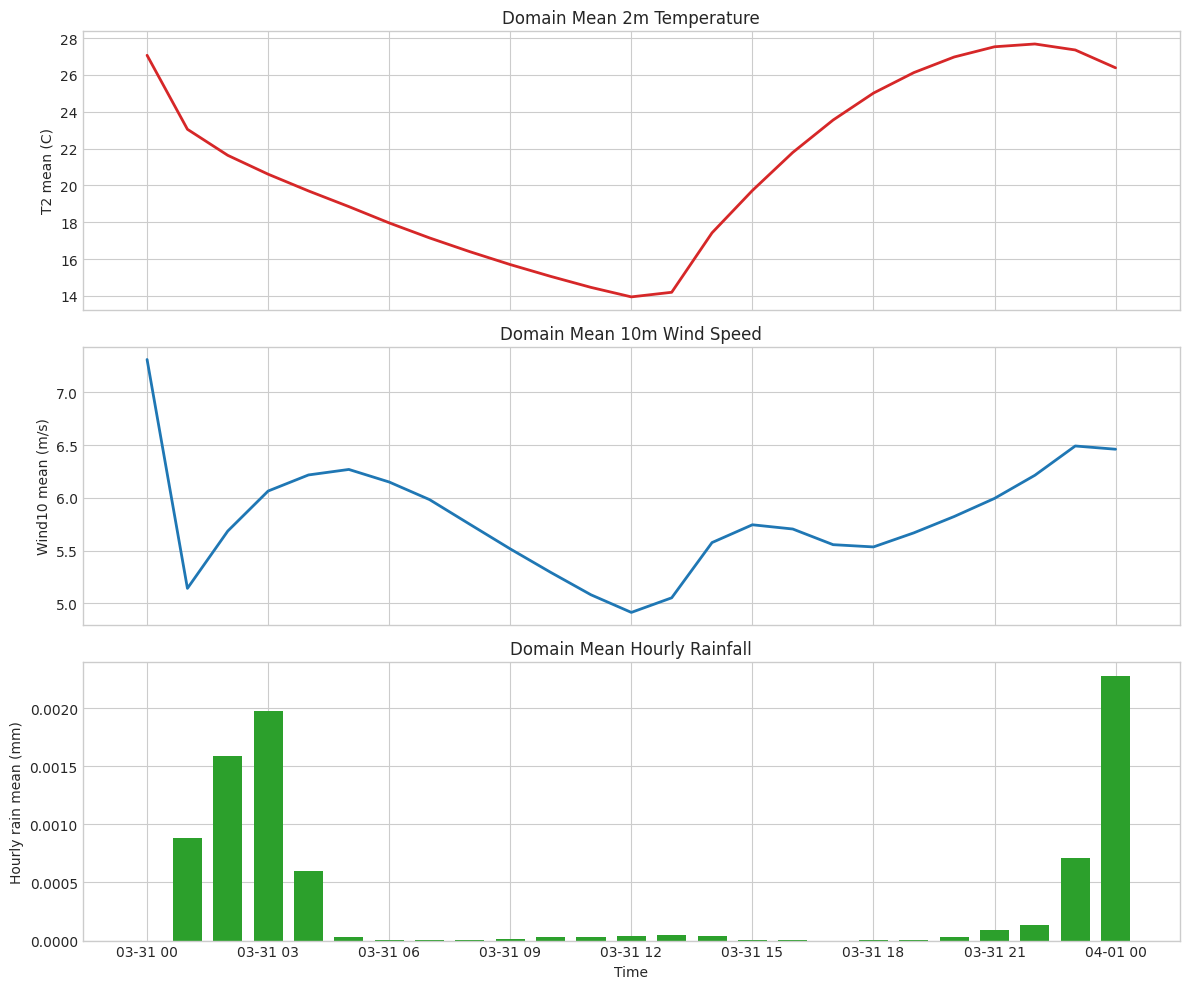

Wrote: /lustre/work/annewaz/nwp/WRFV4.5.2/test/em_real/plot_domain_timeseries.png


In [6]:
fig, ax = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

ax[0].plot(times, summary['t2_domain_mean_C'], color='tab:red', lw=2)
ax[0].set_ylabel('T2 mean (C)')
ax[0].set_title('Domain Mean 2m Temperature')

ax[1].plot(times, summary['wind10_domain_mean_mps'], color='tab:blue', lw=2)
ax[1].set_ylabel('Wind10 mean (m/s)')
ax[1].set_title('Domain Mean 10m Wind Speed')

ax[2].bar(times, summary['rain_hourly_domain_mean_mm'], color='tab:green', width=0.03)
ax[2].set_ylabel('Hourly rain mean (mm)')
ax[2].set_title('Domain Mean Hourly Rainfall')
ax[2].set_xlabel('Time')

plt.tight_layout()
out_png = run_dir / 'plot_domain_timeseries.png'
plt.savefig(out_png, dpi=150)
plt.show()
print(f'Wrote: {out_png}')

## Plot 2: Total event precipitation map

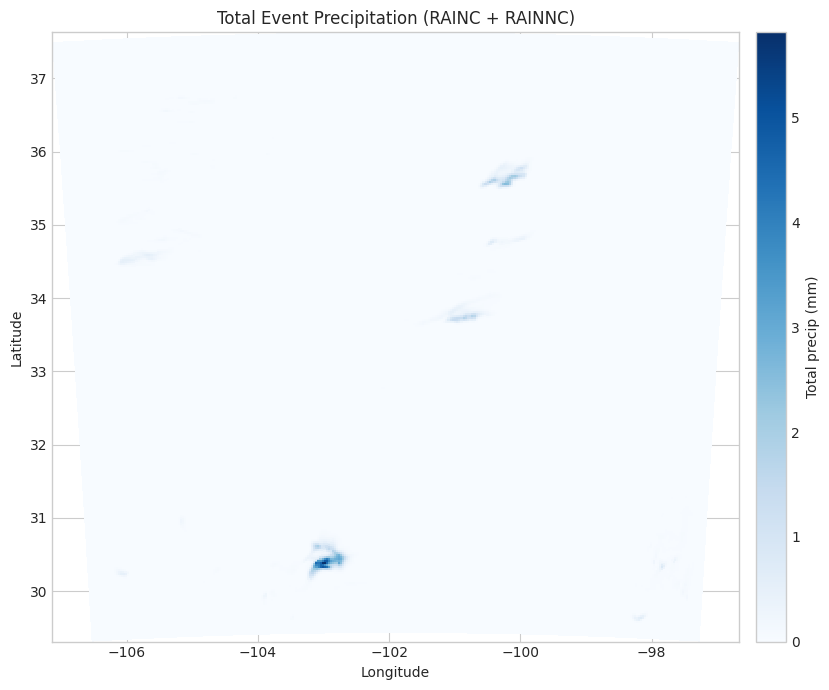

Wrote: /lustre/work/annewaz/nwp/WRFV4.5.2/test/em_real/plot_total_precip_map.png


In [7]:
fig, ax = plt.subplots(figsize=(9, 7))
pcm = ax.pcolormesh(lon, lat, rain_total, cmap='Blues')
cb = plt.colorbar(pcm, ax=ax, pad=0.02)
cb.set_label('Total precip (mm)')

ax.set_title('Total Event Precipitation (RAINC + RAINNC)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.tight_layout()
out_png = run_dir / 'plot_total_precip_map.png'
plt.savefig(out_png, dpi=150)
plt.show()
print(f'Wrote: {out_png}')

## Plot 3: Maximum hourly precipitation map

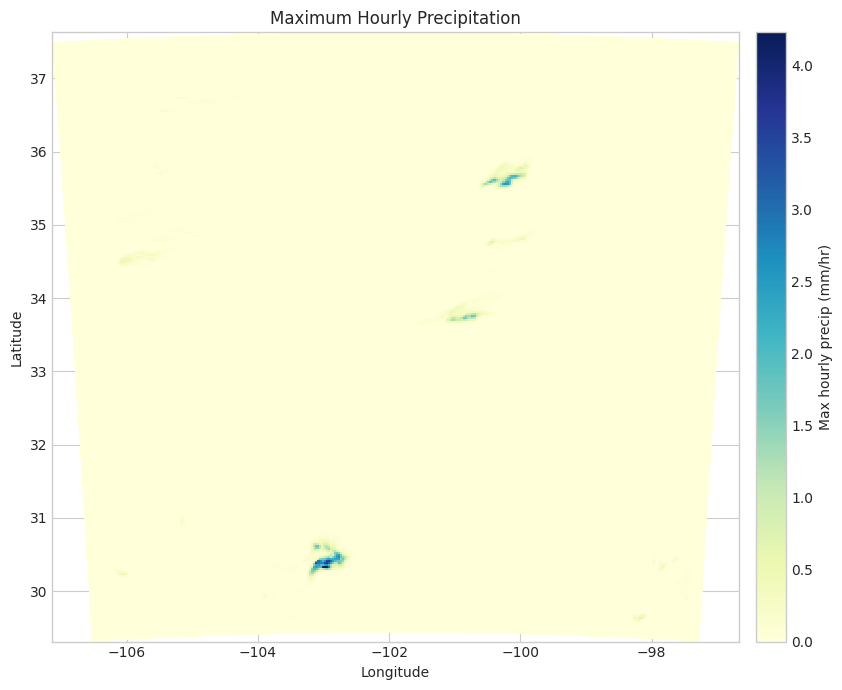

Wrote: /lustre/work/annewaz/nwp/WRFV4.5.2/test/em_real/plot_max_hourly_precip_map.png


In [8]:
rain_hourly_max_map = rain_hourly.max(dim='Time')

fig, ax = plt.subplots(figsize=(9, 7))
pcm = ax.pcolormesh(lon, lat, rain_hourly_max_map, cmap='YlGnBu')
cb = plt.colorbar(pcm, ax=ax, pad=0.02)
cb.set_label('Max hourly precip (mm/hr)')

ax.set_title('Maximum Hourly Precipitation')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.tight_layout()
out_png = run_dir / 'plot_max_hourly_precip_map.png'
plt.savefig(out_png, dpi=150)
plt.show()
print(f'Wrote: {out_png}')

## Plot 4: Snapshot map (2m temperature + 10m wind)

Choose the hour you want to inspect by changing `idx`.

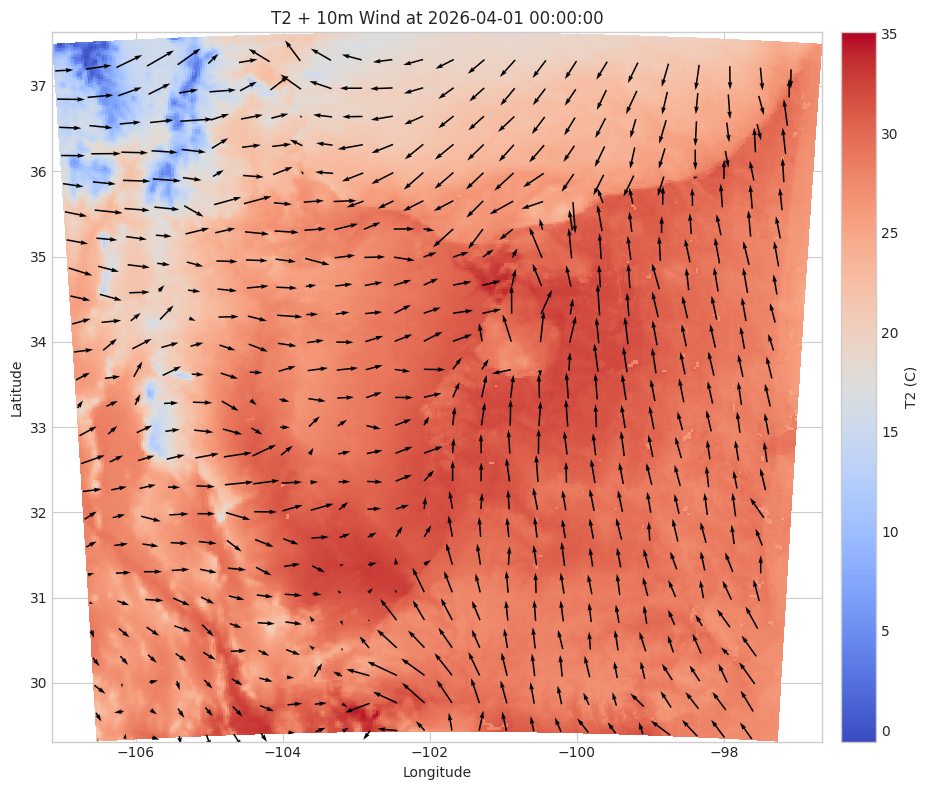

Wrote: /lustre/work/annewaz/nwp/WRFV4.5.2/test/em_real/plot_snapshot_t2_wind.png


In [9]:
idx = -1  # last time step
skip = 12  # wind arrow thinning

t2_now = t2_c.isel(Time=idx)
u10_now = u10.isel(Time=idx)
v10_now = v10.isel(Time=idx)

fig, ax = plt.subplots(figsize=(10, 8))
pcm = ax.pcolormesh(lon, lat, t2_now, cmap='coolwarm')
cb = plt.colorbar(pcm, ax=ax, pad=0.02)
cb.set_label('T2 (C)')

ax.quiver(
    lon.values[::skip, ::skip],
    lat.values[::skip, ::skip],
    u10_now.values[::skip, ::skip],
    v10_now.values[::skip, ::skip],
    scale=250,
    width=0.002
)

ax.set_title(f'T2 + 10m Wind at {times[idx]}')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.tight_layout()
out_png = run_dir / 'plot_snapshot_t2_wind.png'
plt.savefig(out_png, dpi=150)
plt.show()
print(f'Wrote: {out_png}')

## Quick interpretation checklist

- Are high-rainfall locations where you expected storms?
- Is the rain timing peak realistic?
- Is domain-mean temperature trend physically reasonable?
- Are winds too strong/weak compared with station observations?